<a href="https://colab.research.google.com/github/CharuSoni13/dip_lab/blob/main/EXP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving image1.jpg to image1.jpg


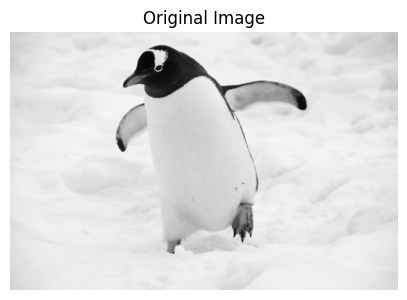

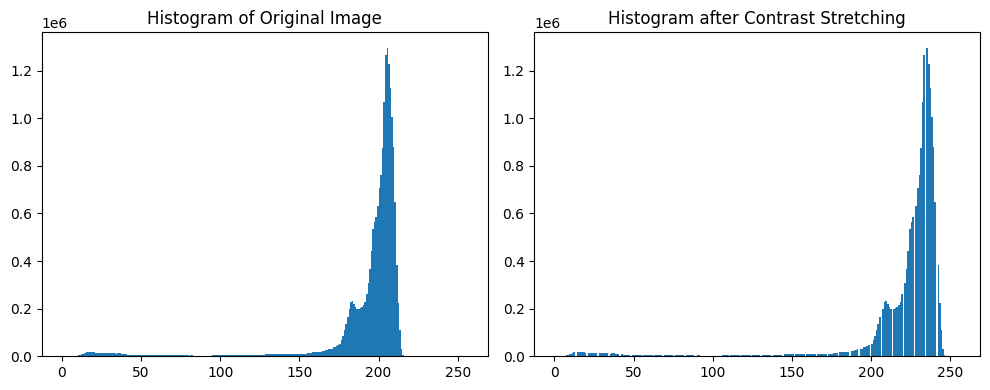

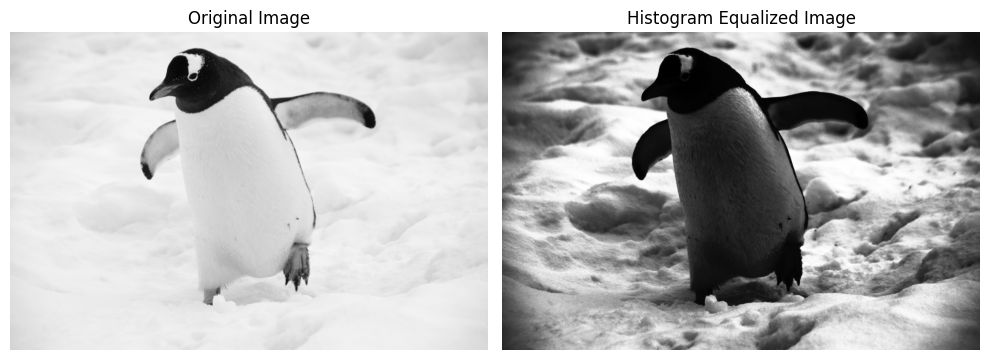

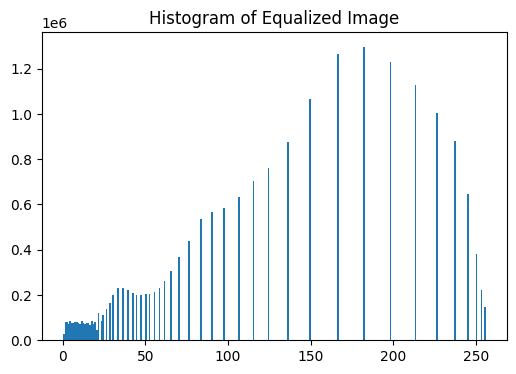

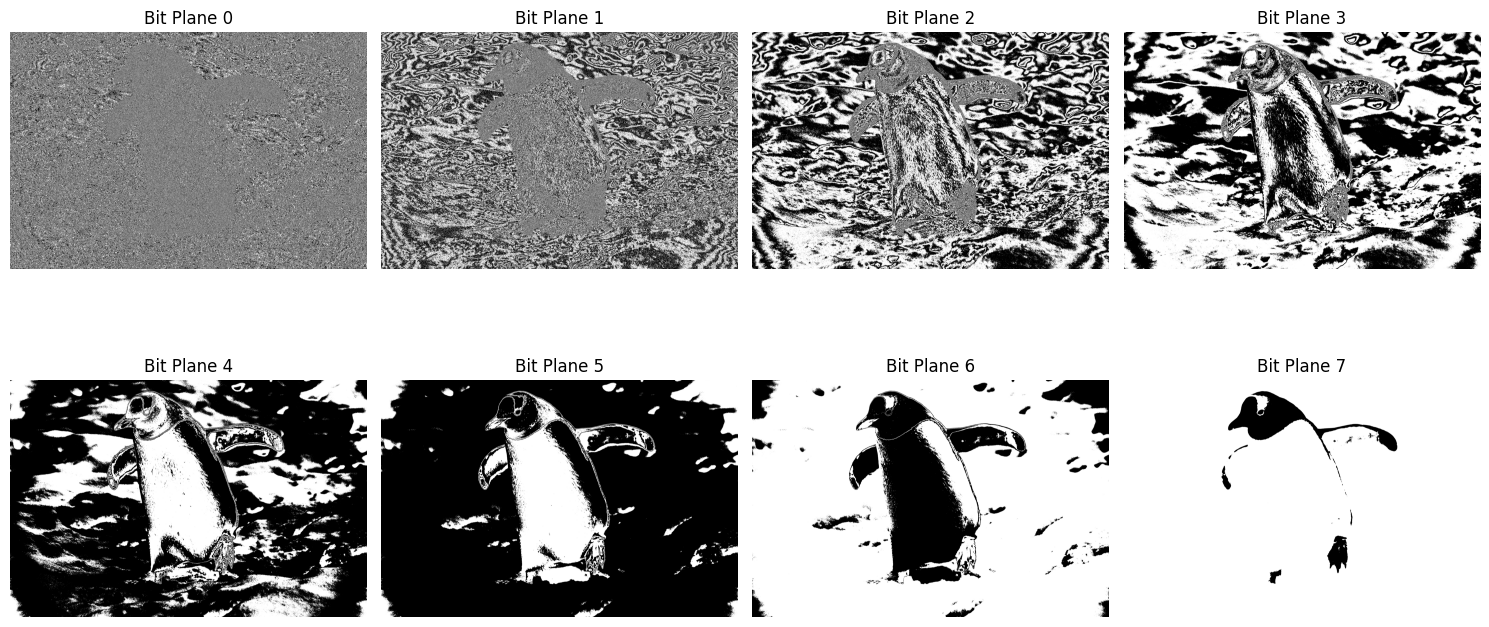

In [ ]:
# ==========================================================
# Contrast Stretching, Histogram Equalization,
# Histogram and Bit Plane Slicing
# ==========================================================

# Install OpenCV
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================================
# STEP 1: Upload Image at Runtime
# ==========================================================

uploaded = files.upload()

# Get uploaded image name automatically
image_name = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_name, 0)

# ==========================================================
# STEP 2: Display Original Image
# ==========================================================

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

# ==========================================================
# STEP 3: Contrast Stretching
# ==========================================================

# Find minimum and maximum intensity
rmin = np.min(img)
rmax = np.max(img)

# Apply contrast stretching
contrast_stretched = ((img - rmin) / (rmax - rmin)) * 255

# Convert to uint8
contrast_stretched = np.uint8(contrast_stretched)

# ==========================================================
# STEP 4: Histogram
# ==========================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Original Image")

plt.subplot(1,2,2)
plt.hist(contrast_stretched.ravel(), bins=256, range=[0,256])
plt.title("Histogram after Contrast Stretching")

plt.tight_layout()
plt.show()

# ==========================================================
# STEP 5: Histogram Equalization
# ==========================================================

equalized_img = cv2.equalizeHist(img)

# ==========================================================
# STEP 6: Display Equalized Image
# ==========================================================

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_img, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# STEP 7: Histogram Equalization Histogram
# ==========================================================

plt.figure(figsize=(6,4))
plt.hist(equalized_img.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Equalized Image")
plt.show()

# ==========================================================
# STEP 8: Bit Plane Slicing
# ==========================================================

plt.figure(figsize=(15,8))

for i in range(8):

    # Extract bit plane
    bit_plane = (img >> i) & 1

    plt.subplot(2,4,i+1)
    plt.imshow(bit_plane, cmap='gray')
    plt.title(f'Bit Plane {i}')
    plt.axis("off")

plt.tight_layout()
plt.show()